In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo')

In [3]:
# 设置标的和日期
instrument_id = '518880'
trade_ymd = '20251219'

# 策略参数配置
param_dict = {
    'instrument_id': instrument_id,
    'trade_ymd': trade_ymd,
    'name': 'delta_v1_demo',
    'stride': 1,

    'short_window': 60,      # 短期窗口
    'long_window': 300,      # 长期窗口
    'y_window': 300,         # 标签窗口

    'open_threshold': 2,     # 开仓阈值
    'open_confidence': 0,    # 开仓置信度
    'close_confidence': 0.2, # 平仓置信度
    'standard_num': 1000,    # 标准数量

    'atr_multiplier': 4,     # 回撤比例
    'vol_window': 900,       # 价格波动窗口

    'k_up': 3,
    'k_down': 3,
}
param_dict['x_window'] = max(param_dict['short_window'], param_dict['long_window'])

In [4]:
model_path = f"/home/jovyan/work/model/delta_v3.pkl"
import joblib
model = joblib.load(model_path)
print(f"模型已加载: {model_path}")

模型已加载: /home/jovyan/work/model/delta_v3.pkl


In [5]:
from delta import strategy 
tactic = strategy.StrategyDemo(model_path, param_dict)

In [6]:
# 单日回测测试
sys.path.append('/home/jovyan/base_demo')
import base_tool
snap_list = base_tool.snap_list_load(instrument_id, trade_ymd)

position_dict = {}
for snap in snap_list:
    tactic.on_snap(snap)
    position_dict[snap['time_mark']] = tactic.position_last

print(f"生成 {len(position_dict)} 个仓位信号")

生成 14402 个仓位信号


-> Python解释器: /opt/conda/bin/python
-> Python版本: 3.13.11 | packaged by conda-forge | (main, Jan 26 2026, 23:57:06) [GCC 14.3.0]
spawn模式启动
-> 当前 Python 解释器: /opt/conda/bin/python
-> 从delta/train.py获取到 77 个有数据的交易日
-> 过滤后剩余 23 个有数据的交易日
-> 过滤掉 8 个无数据日期: ['20251206', '20251207', '20251213', '20251214', '20251220', '20251221', '20251227', '20251228']
-> 回测标的: 518880 (20251201 - 20251231)
-> 任务分配: 共 23 天，使用 4 个核心并行计算...


[SpawnPoolWorker-52] 日期 20251217 完成 | 盈亏: -1.80
[SpawnPoolWorker-53] 日期 20251225 完成 | 盈亏: 2.60
[SpawnPoolWorker-50] 日期 20251209 完成 | 盈亏: 3.80
[SpawnPoolWorker-51] 日期 20251201 完成 | 盈亏: 1.40
[SpawnPoolWorker-53] 日期 20251226 完成 | 盈亏: -1.10
[SpawnPoolWorker-52] 日期 20251218 完成 | 盈亏: -2.80
[SpawnPoolWorker-51] 日期 20251202 完成 | 盈亏: 0.80
[SpawnPoolWorker-50] 日期 20251210 完成 | 盈亏: 2.10
[SpawnPoolWorker-52] 日期 20251219 完成 | 盈亏: -2.10
[SpawnPoolWorker-53] 日期 20251229 完成 | 盈亏: 7.90
[SpawnPoolWorker-51] 日期 20251203 完成 | 盈亏: 0.20
[SpawnPoolWorker-50] 日期 20251211 完成 | 盈亏: 1.00
[SpawnPoolWorker-52] 日期 20251222 完成 | 盈亏: 4.50
[SpawnPoolWorker-50] 日期 20251212 完成 | 盈亏: 1.50
[SpawnPoolWorker-51] 日期 20251204 完成 | 盈亏: 1.00
[SpawnPoolWorker-53] 日期 20251230 完成 | 盈亏: -0.10
[SpawnPoolWorker-50] 日期 20251215 完成 | 盈亏: 0.40
[SpawnPoolWorker-52] 日期 20251223 完成 | 盈亏: -4.10
[SpawnPoolWorker-51] 日期 20251205 完成 | 盈亏: -2.50
[SpawnPoolWorker-53] 日期 20251231 完成 | 盈亏: 8.40
[SpawnPoolWorker-51] 日期 20251208 完成 | 盈亏: -5.90
[Spaw

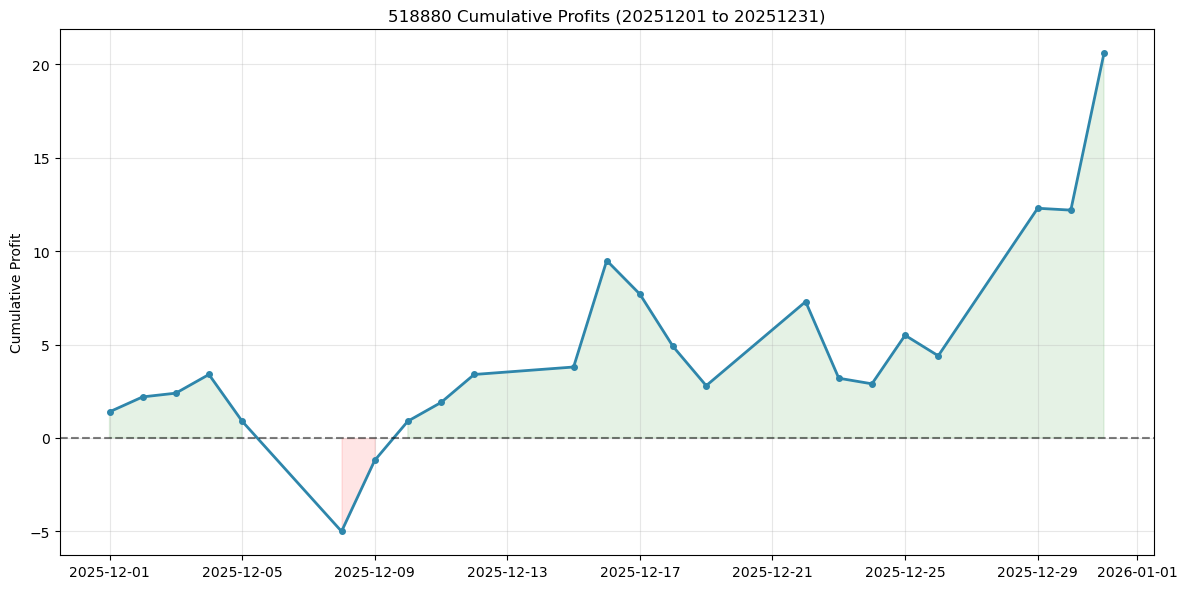


并行回测结果汇总:


{'测试天数': 23,
 '累计总盈亏': np.float64(20.6),
 '总成交次数': 236,
 '日均盈亏': np.float64(0.9),
 '胜率(天)%': 60.87,
 '盈亏比(日均)': np.float64(1.28),
 '最大单日盈利': 8.4,
 '最大单日亏损': -5.9,
 '每笔交易平均盈利': np.float64(0.09)}

In [15]:
# 导入修复的并行回测模块
sys.path.append('/home/jovyan/work/tactics_demo/tools')
from tools.parallel_backtest_simple import run_parallel_backtest
from multi_day_backtest import backtest_summary
# 运行并行回测
result_df = run_parallel_backtest(
    instrument_id="518880",
    start_ymd="20251201",
    end_ymd="20251231",
    StrategyClass=strategy.StrategyDemo,
    model=model_path,
    param_dict=param_dict,
    n_cores=4
)


print("\n并行回测结果汇总:")
backtest_summary(result_df)

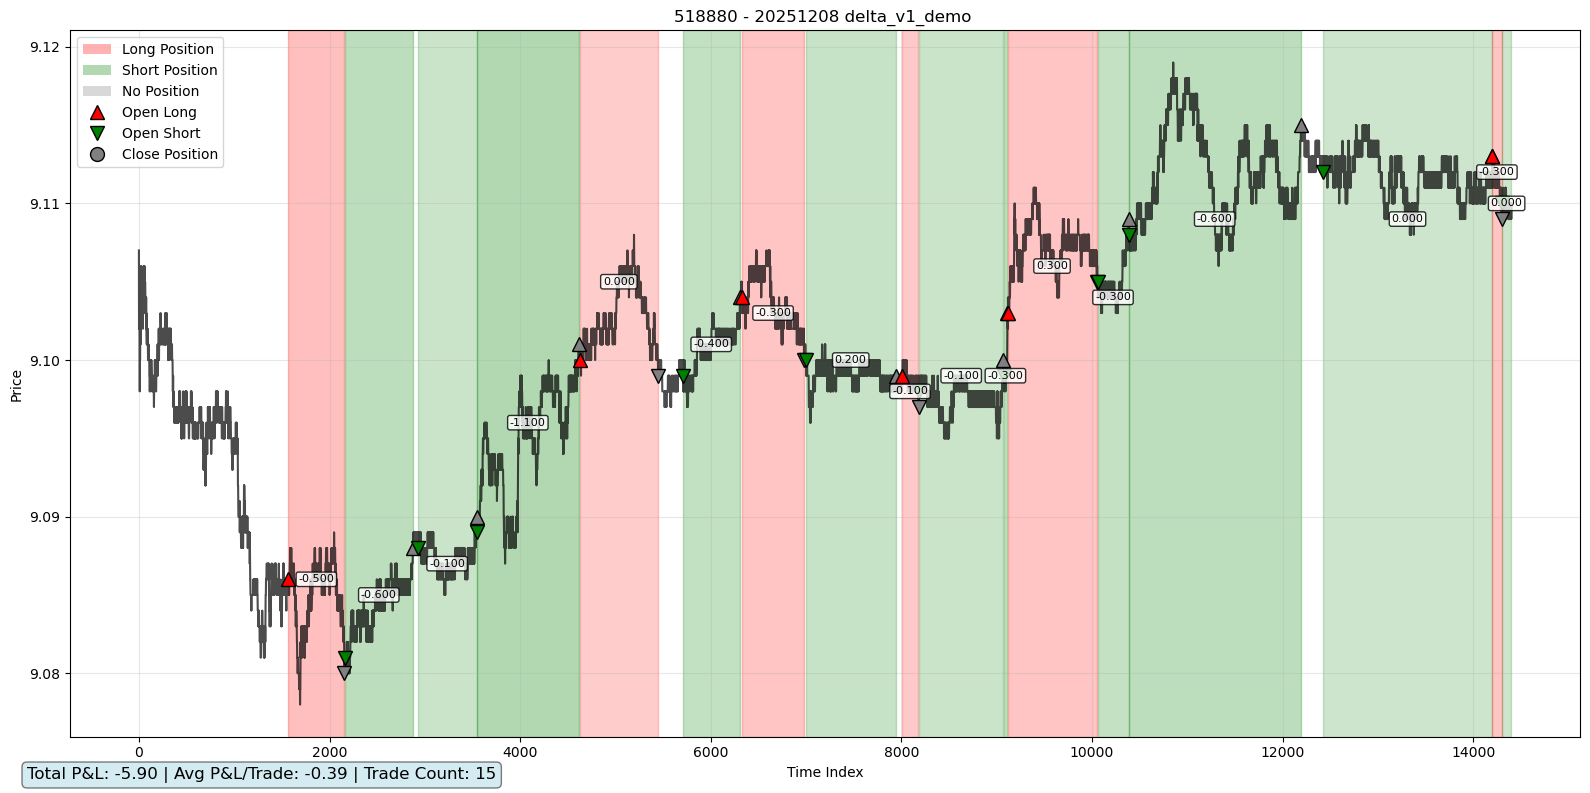

In [18]:
# 执行单日回测
import sys
sys.path.append('/home/jovyan/work/tactics_demo/tools')

from single_day_backtest import single_day_backtest

profit_df = single_day_backtest(
    instrument_id=instrument_id,
    trade_ymd='20251208',
    StrategyClass=strategy.StrategyDemo,
    model=model_path,
    param_dict=param_dict,
    official= False, 
)